In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
!pip install numpy==1.25.0
!pip install gensim

  Using cached scipy-1.13.1-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (60 kB)
Using cached scipy-1.13.1-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (38.6 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tsfresh 0.21.0 requires scipy>=1.14.0; python_version >= "3.10", but you have scipy 1.13.1 which is incompatible.


In [2]:
import numpy as np
print(np.__version__)

1.25.0


In [3]:
!pip install contractions

In [4]:
import pandas as pd
import re
import nltk
import gensim.downloader as api
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from nltk.stem import WordNetLemmatizer, PorterStemmer
import contractions
from nltk.corpus import stopwords

In [5]:
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [6]:
df = pd.read_csv('/content/drive/MyDrive/hatevsoffensive_language.csv')

In [7]:
df.head()

,label,text
0,neither,!!! RT @mayasolovely: As a woman you shouldn't...
1,offensive language,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,offensive language,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,offensive language,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,offensive language,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...


In [8]:
def text_cleaning_pipeline(dataset, rule="lemmatize"):
    """
    Cleans text data: lowercasing, removing URLs, emojis, mentions, non-alphanumeric characters,
    stopwords, and lemmatization or stemming based on the rule.
    """
    # Convert the input to lowercase
    data = dataset.lower()

    # Handle contractions (expand common contractions)
    data = contractions.fix(data)

    # Remove URLs
    data = re.sub(r"http\S+|www\S+|https\S+", '', data, flags=re.MULTILINE)

    # Remove emojis
    data = re.sub(r"["
                        u"\U0001F600-\U0001F64F"  # emoticons
                        u"\U0001F300-\U0001F5FF"  # symbols & pictographs
                        u"\U0001F680-\U0001F6FF"  # transport & map symbols
                        u"\U0001F1E0-\U0001F1FF"  # flags
                        u"\u2702-\u27B0"          # dingbats
                        u"\u24C2-\U0001F251"      # enclosed characters
                        "]+", r' ', data, flags=re.UNICODE)

    # Remove mentions (e.g., @user)
    data = re.sub("@[A-Za-z0-9_]+", " ", data)

    # Remove non-alphanumeric characters (leaving only letters and spaces)
    data = re.sub("[^0-9A-Za-z ]", " ", data)

    # Normalize extra spaces
    data = re.sub(r'\s+', ' ', data).strip()

    # Tokenize the text
    tokens = data.split()

    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    tokens = [token for token in tokens if token not in stop_words]

    # Lemmatization or Stemming
    if rule == "lemmatize":
        lemmatizer = WordNetLemmatizer()
        tokens = [lemmatizer.lemmatize(token) for token in tokens]
    elif rule == "stem":
        stemmer = PorterStemmer()
        tokens = [stemmer.stem(token) for token in tokens]
    else:
        raise ValueError("Pick between 'lemmatize' or 'stem'")

    return " ".join(tokens)
df['clean_text'] = df['text'].apply(lambda x: text_cleaning_pipeline(x, rule="lemmatize"))

In [9]:
X = df['clean_text'].values
y = df['label'].values

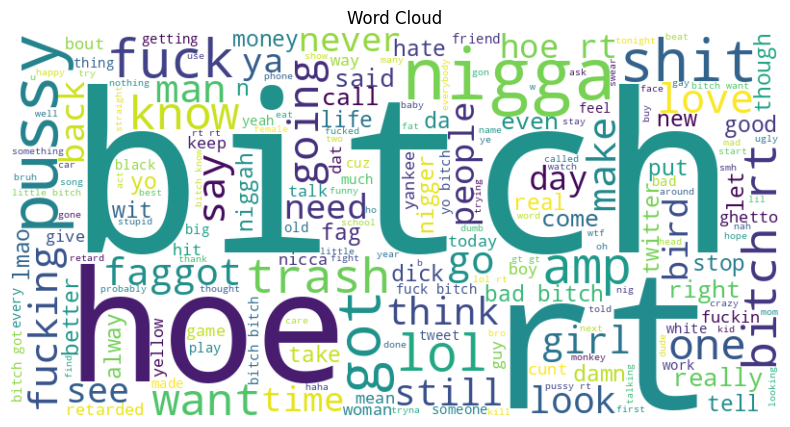

In [10]:
all_clean_text = " ".join(df['clean_text'])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_clean_text)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud")
plt.show()

In [11]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(X)
sequences = tokenizer.texts_to_sequences(X)

max_len = int(np.percentile([len(x) for x in sequences], 95))
X_padded = pad_sequences(sequences, maxlen=max_len, padding='post')

X_train, X_test, y_train, y_test = train_test_split(X_padded, y, test_size=0.2, random_state=42)

print(f"Shape of padded data (X_train): {X_train.shape}")
print(f"Shape of padded data (X_test): {X_test.shape}")

Shape of padded data (X_train): (19826, 16)
Shape of padded data (X_test): (4957, 16)


In [12]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()

y_train = label_encoder.fit_transform(y_train)
y_test = label_encoder.transform(y_test)

print(f"Classes: {label_encoder.classes_}")

Classes: ['hate speec' 'neither' 'offensive language']


In [13]:
from sklearn.utils import class_weight

class_weights = class_weight.compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = {i: class_weights[i] for i in range(len(class_weights))}

print(class_weight_dict)


{0: 5.797076023391813, 1: 1.9857772435897436, 2: 0.4303077657681122}


In [14]:
vocab_size = len(tokenizer.word_index) + 1
print(vocab_size)

18984


In [15]:
rnn_model = Sequential()
rnn_model.add(Embedding(input_dim=vocab_size, output_dim=50, input_length=16))
rnn_model.add(SimpleRNN(64))
rnn_model.add(Dense(3, activation='softmax'))
rnn_model.build(input_shape=(None, 16))
rnn_model.summary()
rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

early_stopping = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)
checkpoint = ModelCheckpoint('rnn_best_model.h5', monitor='val_loss', save_best_only=True, mode='min')

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 16, 50)         │       949,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         7,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 956,755 (3.65 MB)

 Trainable params: 956,755 (3.65 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
rnn_history = rnn_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    class_weight=class_weight_dict,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping, checkpoint]
)

Epoch 1/50
310/310 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6706 - loss: 0.8618

310/310 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.6709 - loss: 0.8615 - val_accuracy: 0.8168 - val_loss: 0.5776
Epoch 2/50
310/310 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8543 - loss: 0.4094 - val_accuracy: 0.7367 - val_loss: 0.6460
Epoch 3/50
310/310 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9070 - loss: 0.2132 - val_accuracy: 0.7759 - val_loss: 0.6247
Epoch 4/50
310/310 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9445 - loss: 0.1313 - val_accuracy: 0.7958 - val_loss: 0.5931
Epoch 5/50
310/310 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9647 - loss: 0.0762 - val_accuracy: 0.7981 - val_loss: 0.6275


In [17]:
lstm_model = Sequential()
lstm_model.add(Embedding(input_dim=vocab_size, output_dim=50))
lstm_model.add(LSTM(64))
lstm_model.add(Dense(3, activation='softmax'))
lstm_model.build((None, 16))
lstm_model.summary()

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
model_checkpoint = ModelCheckpoint("lstm_best_model.h5", monitor='val_loss', save_best_only=True, verbose=1)



Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 16, 50)         │       949,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        29,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 978,835 (3.73 MB)

 Trainable params: 978,835 (3.73 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
history_lstm = lstm_model.fit(X_train, y_train, epochs=50, batch_size=32,class_weight=class_weight_dict, validation_split=0.1,
                              callbacks=[early_stopping, model_checkpoint], verbose=1)

Epoch 1/50
554/558 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7192 - loss: 0.8383
Epoch 1: val_loss improved from inf to 0.44529, saving model to lstm_best_model.h5


558/558 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.7198 - loss: 0.8371 - val_accuracy: 0.8704 - val_loss: 0.4453
Epoch 2/50
548/558 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8537 - loss: 0.3950
Epoch 2: val_loss did not improve from 0.44529
558/558 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8535 - loss: 0.3950 - val_accuracy: 0.7660 - val_loss: 0.6382
Epoch 3/50
557/558 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8826 - loss: 0.2694
Epoch 3: val_loss did not improve from 0.44529
558/558 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.8826 - loss: 0.2693 - val_accuracy: 0.8139 - val_loss: 0.4983
Epoch 4/50
556/558 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9197 - loss: 0.1780
Epoch 4: val_loss improved from 0.44529 to 0.44392, saving model to lstm_best_model.h5


558/558 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.9197 - loss: 0.1781 - val_accuracy: 0.8386 - val_loss: 0.4439
Epoch 5/50
557/558 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9374 - loss: 0.1347
Epoch 5: val_loss did not improve from 0.44392
558/558 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.9374 - loss: 0.1347 - val_accuracy: 0.8074 - val_loss: 0.5806
Epoch 6/50
548/558 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9449 - loss: 0.1112
Epoch 6: val_loss did not improve from 0.44392
558/558 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9449 - loss: 0.1114 - val_accuracy: 0.8164 - val_loss: 0.5865
Epoch 7/50
551/558 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9530 - loss: 0.0990
Epoch 7: val_loss did not improve from 0.44392
558/558 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9530 - loss: 0.0990 - val_accuracy: 0.7610 - val_loss: 0.7511


In [19]:
embedding_model = api.load('glove-wiki-gigaword-50')
embedding_dim = 50
embedding_matrix = np.zeros((vocab_size, embedding_dim))
for word, i in tokenizer.word_index.items():
    if word in embedding_model:
        embedding_vector = embedding_model[word]
        embedding_matrix[i] = embedding_vector
    else:
        pass

lstm_glove_model = Sequential()
lstm_glove_model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim,
                               weights=[embedding_matrix], input_length=max_len,
                               trainable=False))
lstm_glove_model.add(LSTM(64))
lstm_glove_model.add(Dense(3, activation='softmax'))
lstm_glove_model.build((None, max_len))

lstm_glove_model.summary()

lstm_glove_model.compile(loss='sparse_categorical_crossentropy',
                         optimizer='adam',
                         metrics=['accuracy'])
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
model_checkpoint = ModelCheckpoint("lstm_glove_best_model.h5", monitor='val_loss', save_best_only=True, verbose=1)


[==================================================] 100.0% 66.0/66.0MB downloaded


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 16, 50)         │       949,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        29,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 978,835 (3.73 MB)

 Trainable params: 29,635 (115.76 KB)

 Non-trainable params: 949,200 (3.62 MB)

In [20]:
history_lstm_glove = lstm_glove_model.fit(X_train, y_train, epochs=50, batch_size=32, class_weight=class_weight_dict, validation_split=0.1,
                                          callbacks=[early_stopping, model_checkpoint], verbose=1)


Epoch 1/50
551/558 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7113 - loss: 0.8472
Epoch 1: val_loss improved from inf to 0.63116, saving model to lstm_glove_best_model.h5


558/558 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7117 - loss: 0.8458 - val_accuracy: 0.7811 - val_loss: 0.6312
Epoch 2/50
558/558 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7942 - loss: 0.5677
Epoch 2: val_loss improved from 0.63116 to 0.54927, saving model to lstm_glove_best_model.h5


558/558 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.7941 - loss: 0.5677 - val_accuracy: 0.8149 - val_loss: 0.5493
Epoch 3/50
557/558 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8093 - loss: 0.5163
Epoch 3: val_loss did not improve from 0.54927
558/558 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8093 - loss: 0.5163 - val_accuracy: 0.7388 - val_loss: 0.6302
Epoch 4/50
549/558 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7988 - loss: 0.4680
Epoch 4: val_loss improved from 0.54927 to 0.50732, saving model to lstm_glove_best_model.h5


558/558 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.7988 - loss: 0.4683 - val_accuracy: 0.8159 - val_loss: 0.5073
Epoch 5/50
553/558 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8008 - loss: 0.4351
Epoch 5: val_loss did not improve from 0.50732
558/558 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8008 - loss: 0.4352 - val_accuracy: 0.7958 - val_loss: 0.5138
Epoch 6/50
553/558 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8024 - loss: 0.4299
Epoch 6: val_loss improved from 0.50732 to 0.43100, saving model to lstm_glove_best_model.h5


558/558 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8025 - loss: 0.4298 - val_accuracy: 0.8371 - val_loss: 0.4310
Epoch 7/50
553/558 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8119 - loss: 0.3870
Epoch 7: val_loss did not improve from 0.43100
558/558 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8119 - loss: 0.3870 - val_accuracy: 0.8003 - val_loss: 0.4856
Epoch 8/50
557/558 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8128 - loss: 0.3682
Epoch 8: val_loss did not improve from 0.43100
558/558 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8128 - loss: 0.3682 - val_accuracy: 0.8003 - val_loss: 0.4997
Epoch 9/50
558/558 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8311 - loss: 0.3274
Epoch 9: val_loss did not improve from 0.43100
558/558 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8311 - loss: 0.3275 - val_accuracy: 0.8285 - val_loss: 0.4574


In [21]:
def plot_training_history(history, model_name):
    plt.figure(figsize=(12, 6))
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{model_name} - Training vs Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

    plt.figure(figsize=(12, 6))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{model_name} - Training vs Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

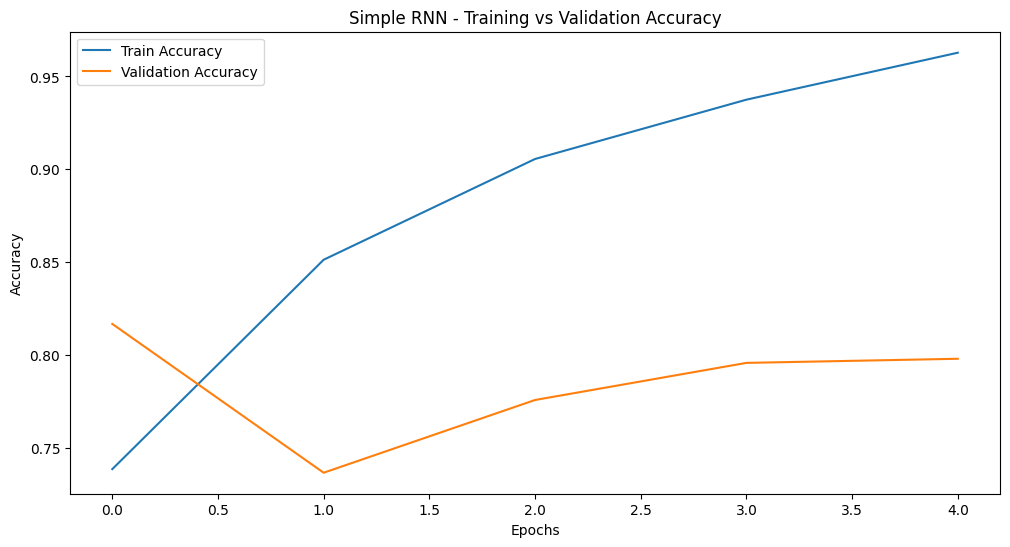

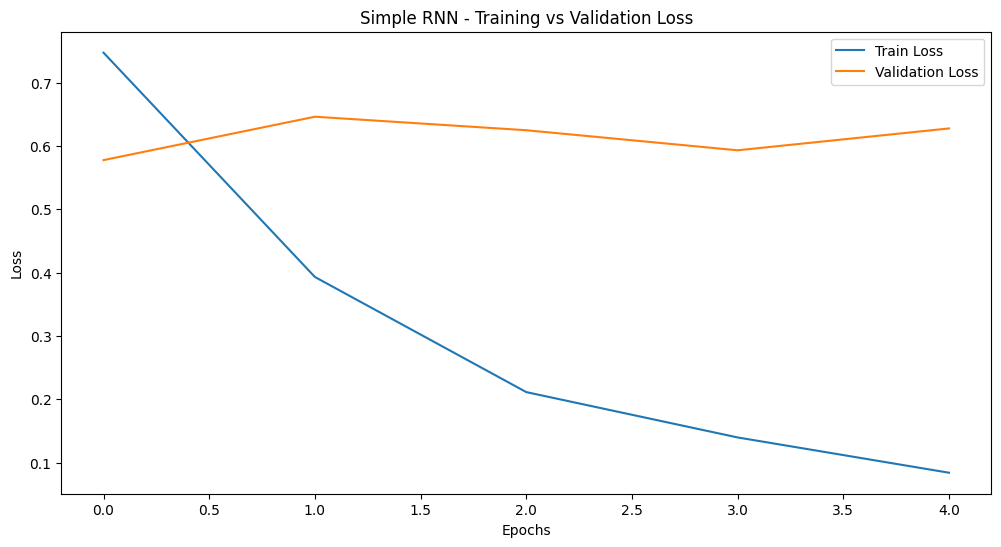

In [22]:
plot_training_history(rnn_history, "Simple RNN")


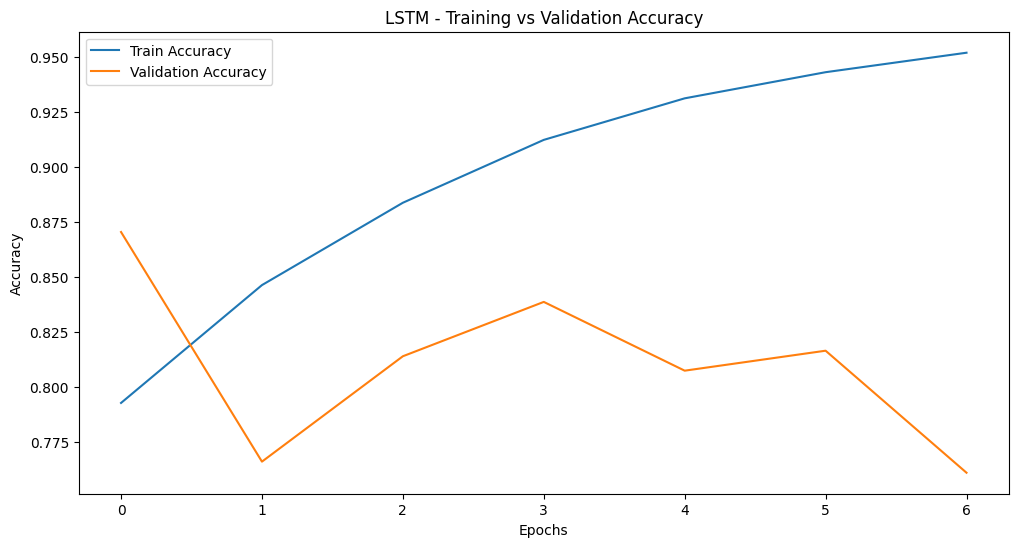

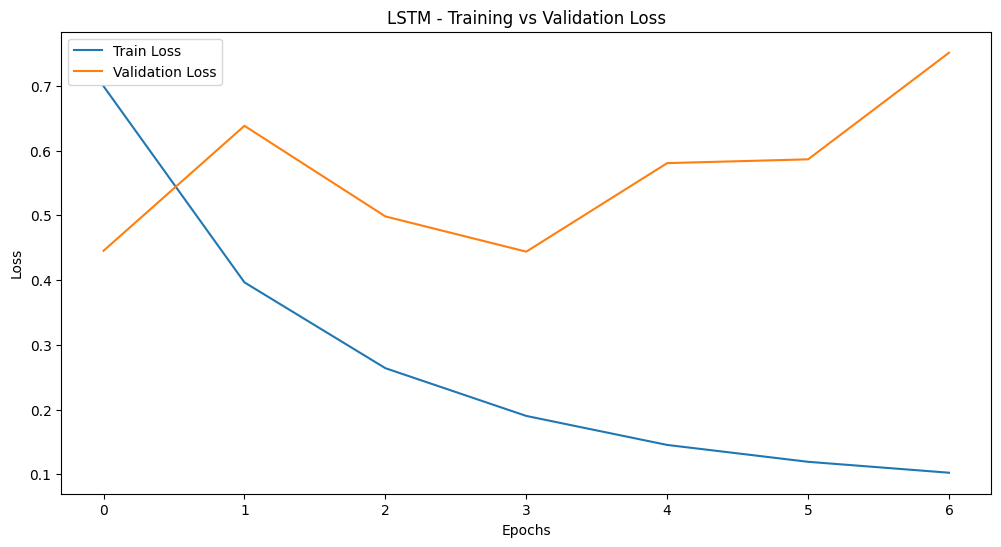

In [23]:
plot_training_history(history_lstm, "LSTM")

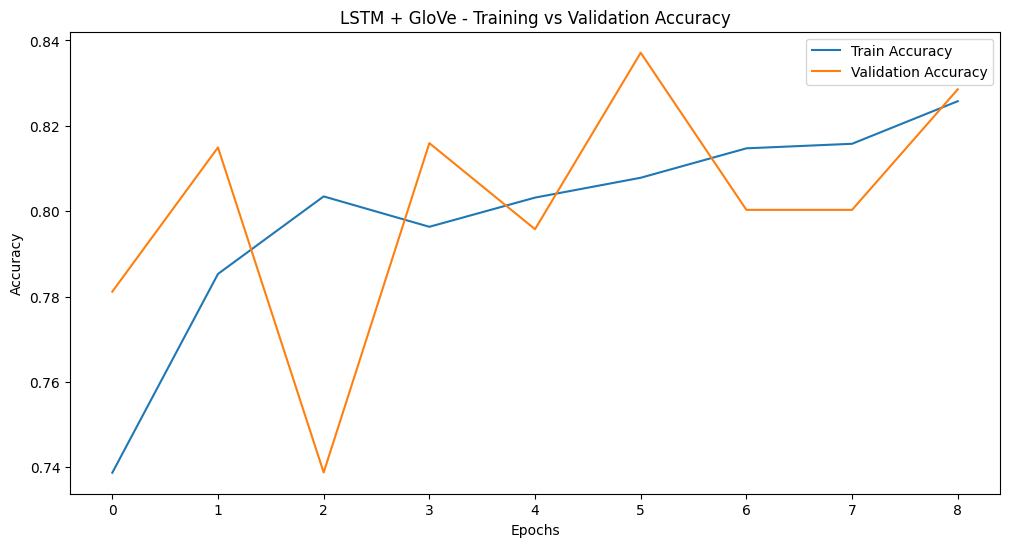

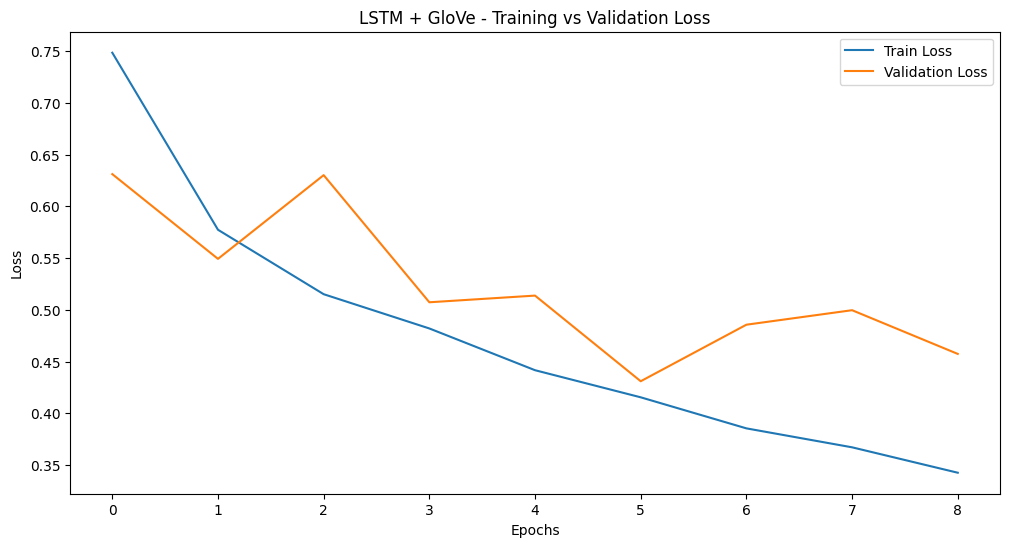

In [24]:
plot_training_history(history_lstm_glove, "LSTM + GloVe")

In [25]:
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test).argmax(axis=1)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"{model_name} Accuracy: {accuracy:.4f}")
    print(f"{model_name} Classification Report:")
    print(classification_report(y_test, y_pred))
    plt.figure(figsize=(8, 6))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
    plt.title(f'{model_name} - Confusion Matrix')
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.show()


155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Simple RNN Accuracy: 0.8168
Simple RNN Classification Report:
              precision    recall  f1-score   support

           0       0.24      0.54      0.33       290
           1       0.70      0.86      0.78       835
           2       0.97      0.83      0.89      3832

    accuracy                           0.82      4957
   macro avg       0.64      0.75      0.67      4957
weighted avg       0.88      0.82      0.84      4957



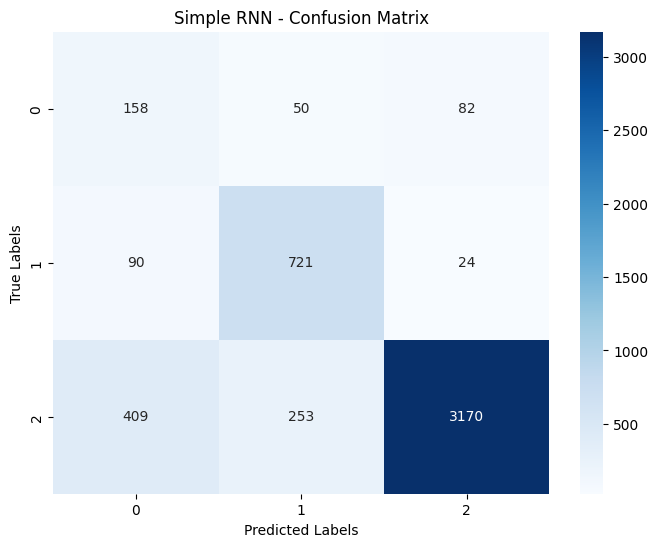

In [26]:
evaluate_model(rnn_model, X_test, y_test, "Simple RNN")

155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
LSTM Accuracy: 0.8303
LSTM Classification Report:
              precision    recall  f1-score   support

           0       0.25      0.52      0.33       290
           1       0.78      0.85      0.82       835
           2       0.95      0.85      0.90      3832

    accuracy                           0.83      4957
   macro avg       0.66      0.74      0.68      4957
weighted avg       0.88      0.83      0.85      4957



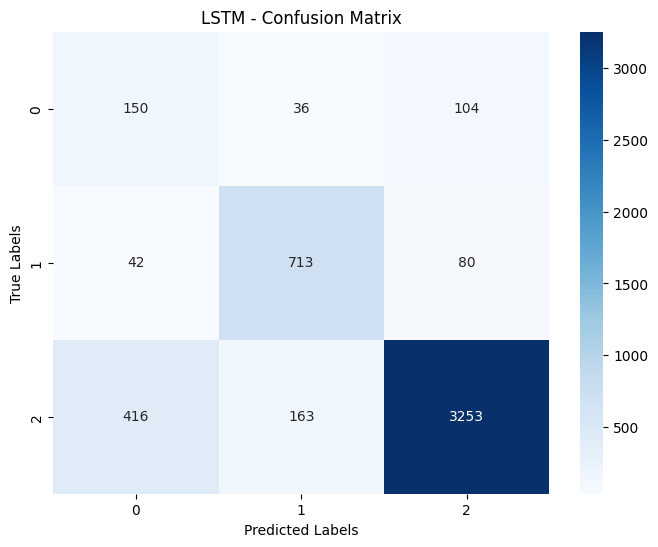

In [27]:
evaluate_model(lstm_model, X_test, y_test, "LSTM")

155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
LSTM + GloVe Accuracy: 0.8322
LSTM + GloVe Classification Report:
              precision    recall  f1-score   support

           0       0.30      0.64      0.40       290
           1       0.72      0.87      0.79       835
           2       0.97      0.84      0.90      3832

    accuracy                           0.83      4957
   macro avg       0.66      0.78      0.70      4957
weighted avg       0.89      0.83      0.85      4957



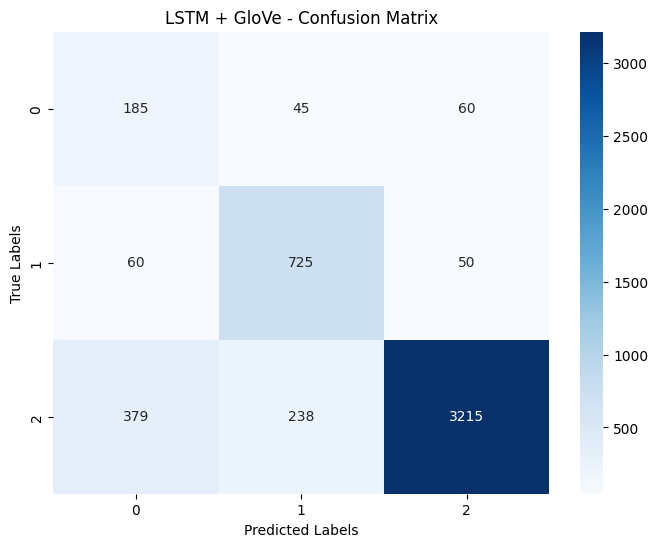

In [28]:
evaluate_model(lstm_glove_model, X_test, y_test, "LSTM + GloVe")

In [29]:
!pip install streamlit

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 126.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 111.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 9.1 MB/s eta 0:00:00


In [30]:
streamlit_code = """
import streamlit as st
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import load_model
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import contractions
from tensorflow.keras.preprocessing.text import Tokenizer

# Download NLTK data
nltk.download('stopwords')
nltk.download('wordnet')

# Load the label encoder used during training
label_encoder = LabelEncoder()
label_encoder.fit(['hate speech', 'offensive language', 'neither'])

# Load all models
rnn_model = load_model("rnn_best_model.h5")  # Simple RNN model
lstm_model = load_model("lstm_best_model.h5")  # LSTM model
lstm_glove_model = load_model("lstm_glove_best_model.h5")  # LSTM with GloVe embeddings

# Preprocessing function (same as during training)
def text_cleaning_pipeline(text, rule="lemmatize"):
    # Convert the input to lowercase
    data = text.lower()

    # Handle contractions (expand common contractions)
    data = contractions.fix(data)

    # Remove URLs
    data = re.sub(r"http\S+|www\S+|https\S+", '', data, flags=re.MULTILINE)

    # Remove emojis
    data = re.sub(r"["
                        u"\U0001F600-\U0001F64F"  # emoticons
                        u"\U0001F300-\U0001F5FF"  # symbols & pictographs
                        u"\U0001F680-\U0001F6FF"  # transport & map symbols
                        u"\U0001F1E0-\U0001F1FF"  # flags
                        u"\u2702-\u27B0"          # dingbats
                        u"\u24C2-\U0001F251"      # enclosed characters
                        "]+", r' ', data, flags=re.UNICODE)

    # Remove mentions (e.g., @user)
    data = re.sub("@[A-Za-z0-9_]+", " ", data)

    # Remove non-alphanumeric characters (leaving only letters and spaces)
    data = re.sub("[^0-9A-Za-z ]", " ", data)

    # Normalize extra spaces
    data = re.sub(r'\s+', ' ', data).strip()

    # Tokenize the text
    tokens = data.split()

    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    tokens = [token for token in tokens if token not in stop_words]

    # Lemmatization or Stemming
    if rule == "lemmatize":
        lemmatizer = WordNetLemmatizer()
        tokens = [lemmatizer.lemmatize(token) for token in tokens]
    elif rule == "stem":
        stemmer = PorterStemmer()
        tokens = [stemmer.stem(token) for token in tokens]
    else:
        raise ValueError("Pick between 'lemmatize' or 'stem'")

    return " ".join(tokens)

# Function to process the input text and make a prediction
def predict_sentiment(text, model):
    # Clean the text
    cleaned_text = text_cleaning_pipeline(text)

    # Tokenize and pad the cleaned text
    tokenizer = Tokenizer()
    tokenizer.fit_on_texts([cleaned_text])  # Fit the tokenizer on the cleaned text
    sequence = tokenizer.texts_to_sequences([cleaned_text])
    max_len = 16  # Use the max sequence length from the training
    padded_sequence = pad_sequences(sequence, maxlen=max_len, padding='post')

    # Make prediction
    prediction = model.predict(padded_sequence).argmax(axis=1)  # Get the predicted class index
    label = label_encoder.inverse_transform(prediction)  # Convert index to label
    return label[0]

# Streamlit GUI
st.title("Real-Time Tweet Sentiment Prediction")

# Dropdown for selecting the model
model_choice = st.selectbox(
    "Choose a model for prediction:",
    ("Simple RNN", "LSTM", "LSTM with GloVe")
)

# Input from user
tweet = st.text_area("Enter a tweet for sentiment classification:")

# Load the selected model
if model_choice == "Simple RNN":
    selected_model = rnn_model
elif model_choice == "LSTM":
    selected_model = lstm_model
else:
    selected_model = lstm_glove_model

# Predict button
if st.button('Predict'):
    if tweet:
        label = predict_sentiment(tweet, selected_model)
        st.write(f"The predicted sentiment is: **{label}**")
    else:
        st.write("Please enter a tweet to classify.")

"""

with open('app.py', 'w') as f:
    f.write(streamlit_code)
